# 04 QUBO 建模與退火求解

## 從均值—變異數到 QUBO

把資金切成 $P$ 份（lot），令 $x_i \in \{0, \dots, P\}$ 為第 $i$ 檔股票分到的份數，$w_i = x_i / P$。
每個整數用**有界二進位展開**表示為 $x_i = \sum_k c_k b_{ik}$，$b_{ik} \in \{0, 1\}$
（$P=20$：$c = (1,2,4,8,5)$；$P=100$：$c = (1,2,4,8,16,32,37)$）。

目標函數（最小化）：

$$
\underbrace{\frac{\gamma}{2P^2}\, x^\top \Sigma x - \frac{1}{P}\, \mu^\top x}_{\text{均值—變異數}} \;+\; \underbrace{\lambda \Big(\sum_i x_i - P\Big)^2}_{\text{預算限制 penalty}}
$$

GMVP 則只保留 $\frac{1}{P^2} x^\top \Sigma x$。

**λ 的選擇**：令 $L$ 為「每多（或少）配置一個 lot 能換到的最大目標改善量」的上界。因為整數違反量 $d$ 的 penalty $\lambda d^2 \ge \lambda |d|$，只要 $\lambda > L$，最低能量解必然滿足預算限制。本研究取 $\lambda = 2L$。

**為什麼 MSRP 要用 γ 掃描？** Sharpe ratio 不是二次式，無法直接寫成 QUBO。因此在 $\gamma \in \{0.5, 1, 2, 5, 10, 20, 50\}$ 上各解一次，再加上 GMVP 解，取**事前 Sharpe 最高**者作為 QUBO 版的 MSRP。

**Solver**：D-Wave Ocean 的 `neal.SimulatedAnnealingSampler`（古典模擬退火，CPU 上執行）。
**本研究未使用量子硬體**；[`samplers.py`](../src/qaportfolio/samplers.py) 已預留 QPU／Leap hybrid 介面。

實作：[`src/qaportfolio/qubo.py`](../src/qaportfolio/qubo.py)。

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from qaportfolio.config import load_config
from qaportfolio.pipeline import schedule_from_cfg, load_prices
from qaportfolio import analysis, plotting
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 30)
cfg = load_config()
schedule = schedule_from_cfg(cfg)
SUMMARY = cfg["paths"]["results"] / "summary"

## 1. 實際建出一個 QUBO

In [2]:
from qaportfolio import qubo
q = schedule[0].quarter; d = cfg["paths"]["results"] / q
mu = pd.read_csv(d / "mu.csv", dtype={"stock_id": str}).set_index("stock_id")["mu"]
cov = pd.read_csv(d / f"cov_{cfg['covariance']['primary']}.csv", index_col=0)
cov.index = cov.index.astype(str); cov.columns = cov.columns.astype(str)
for P in (20, 100):
    prob = qubo.build_qubo(mu.values, cov.loc[mu.index, mu.index].values, P, gamma=5.0, penalty_factor=cfg["qubo"]["penalty_factor"])
    print(f"P={P:>3}: 每檔 {len(prob.coefs)} bits {prob.coefs.astype(int).tolist()} → {prob.bqm.num_variables} 個二元變數, "
          f"{prob.bqm.num_interactions:,} 個交互作用項, λ = {prob.lagrange:.4g}")

P= 20: 每檔 5 bits [1, 2, 4, 8, 5] → 250 個二元變數, 31,125 個交互作用項, λ = 0.003256
P=100: 每檔 7 bits [1, 2, 4, 8, 16, 32, 37] → 350 個二元變數, 61,075 個交互作用項, λ = 0.0006421


這個 QUBO 是**全連接**的：共變異數讓每一對資產都有交互作用，預算 penalty 展開後更讓所有 bit 彼此相連（rank-one 的 $aa^\top$ 項）。
D-Wave Advantage 的 Pegasus 拓撲能直接嵌入的完全圖約只有 177 個邏輯變數，因此 P=20（250 變數）與 P=100（350 變數）都無法直接放上 QPU，需要縮減問題規模或使用 hybrid solver。

## 2. 解的品質：與連續最佳解的確定等值報酬損失

In [3]:
qmv = pd.read_csv(SUMMARY / "quality_mv.csv")
qmv["ce_loss_bp"] = qmv["ce_loss"] * 1e4; qmv["round_ce_loss_bp"] = qmv["round_ce_loss"] * 1e4
qmv.pivot(index="gamma", columns="method", values=["ce_loss_bp", "round_ce_loss_bp", "feasible_rate"]).round(2)

ce_loss_bp          round_ce_loss_bp          feasible_rate         
method   QUBO-P100 QUBO-P20        QUBO-P100 QUBO-P20     QUBO-P100 QUBO-P20
gamma                                                                       
0.5000    595.7200  49.9700          -0.0000   0.0000        0.0000   0.0000
1.0000    556.4400  32.8100           0.0000   0.0400        0.0300   0.0000
2.0000    507.0600  66.5400           0.0000   0.1900        0.2100   0.0000
5.0000    291.1200  45.4000           0.0400   0.9500        0.8500   0.5400
10.0000   223.5900  80.0400           0.1100   1.9700        0.9900   0.9700
20.0000   221.6800 142.9700           0.2500   4.4500        0.9800   0.9900
50.0000   383.9300 305.5900           0.6300  17.6700        0.9500   0.9900

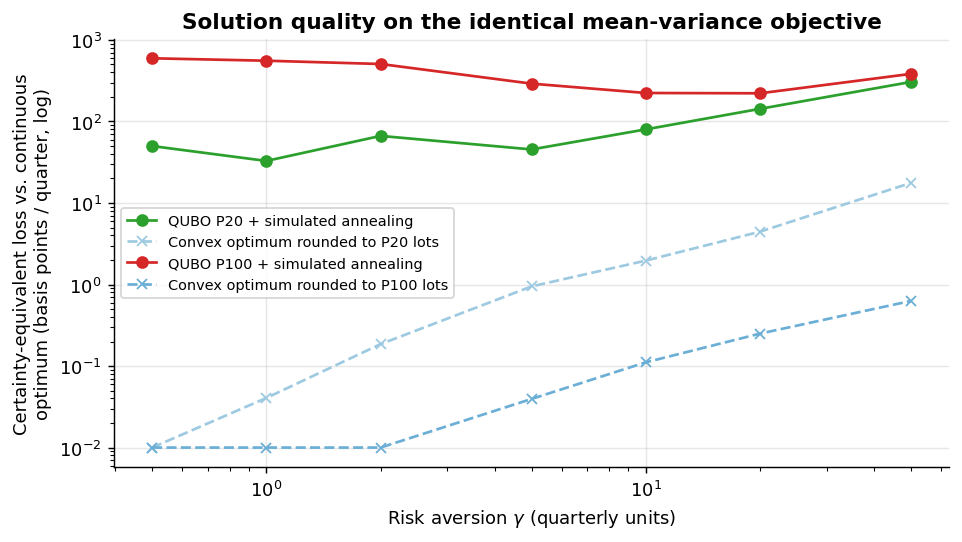

In [4]:
from IPython.display import Image
Image(filename=str(cfg["paths"]["results"] / "figures" / "solver_quality.png"))

**解讀**

* QUBO＋模擬退火的解在**完全相同的目標函數**下，平均每季損失約 1.0（P=20）～4.0（P=100）個百分點的確定等值報酬。
* 把凸最佳解直接四捨五入到同樣的 1/P 格點，損失幾乎為 0。因此損失**不是來自離散化**，而是來自退火在 penalty 主導的能量地形上找不到好的可行解。
* P=100 比 P=20 更差：位元數更多、最高位係數（37）更大，單一位元翻轉造成的能量跳動更劇烈，提高精度反而讓搜尋更困難（精度陷阱）。
* γ 較小時（偏重報酬），預算可行率顯著下降：目標函數線性項的拉力相對變大，λ = 0.1L 不足以把解壓回預算面上，這些解須經修復。

penalty 係數與 sweeps 的敏感度實驗見 `results/figures/penalty_sensitivity.png`：penalty 越小，解越好；sweeps 增加 16 倍幾乎沒有幫助。

## 3. GMVP：波動度相對於凸最佳解

In [5]:
pd.read_csv(SUMMARY / "quality_gmvp.csv", index_col=0)

,vol_ratio,round_vol_ratio,feasible_rate,time
method,,,,
QUBO-P100,1.3083,1.0007,0.8987,159.1470
QUBO-P20,1.2145,1.0103,0.9676,6.1831


## 4. 求解時間（中位數，秒）

In [6]:
pd.read_csv(SUMMARY / "timing.csv", index_col=0)

,GMVP,MSRP,MV
method,,,
QUBO-P100,156.4640,NaN,154.9390
QUBO-P20,6.0239,NaN,5.9299
SA-cont,2.5044,2.5375,NaN


## 5. QUBO-MSRP 選到的 γ

In [7]:
pd.read_csv(SUMMARY / "msrp_gamma.csv", index_col=0)

,1.0,2.0,5.0,10.0,20.0,repaired_share
method,,,,,,
QUBO-P100,2,3,10,9,1,0.1200
QUBO-P20,0,0,2,20,3,0.0000


## 6. 權重與分散程度

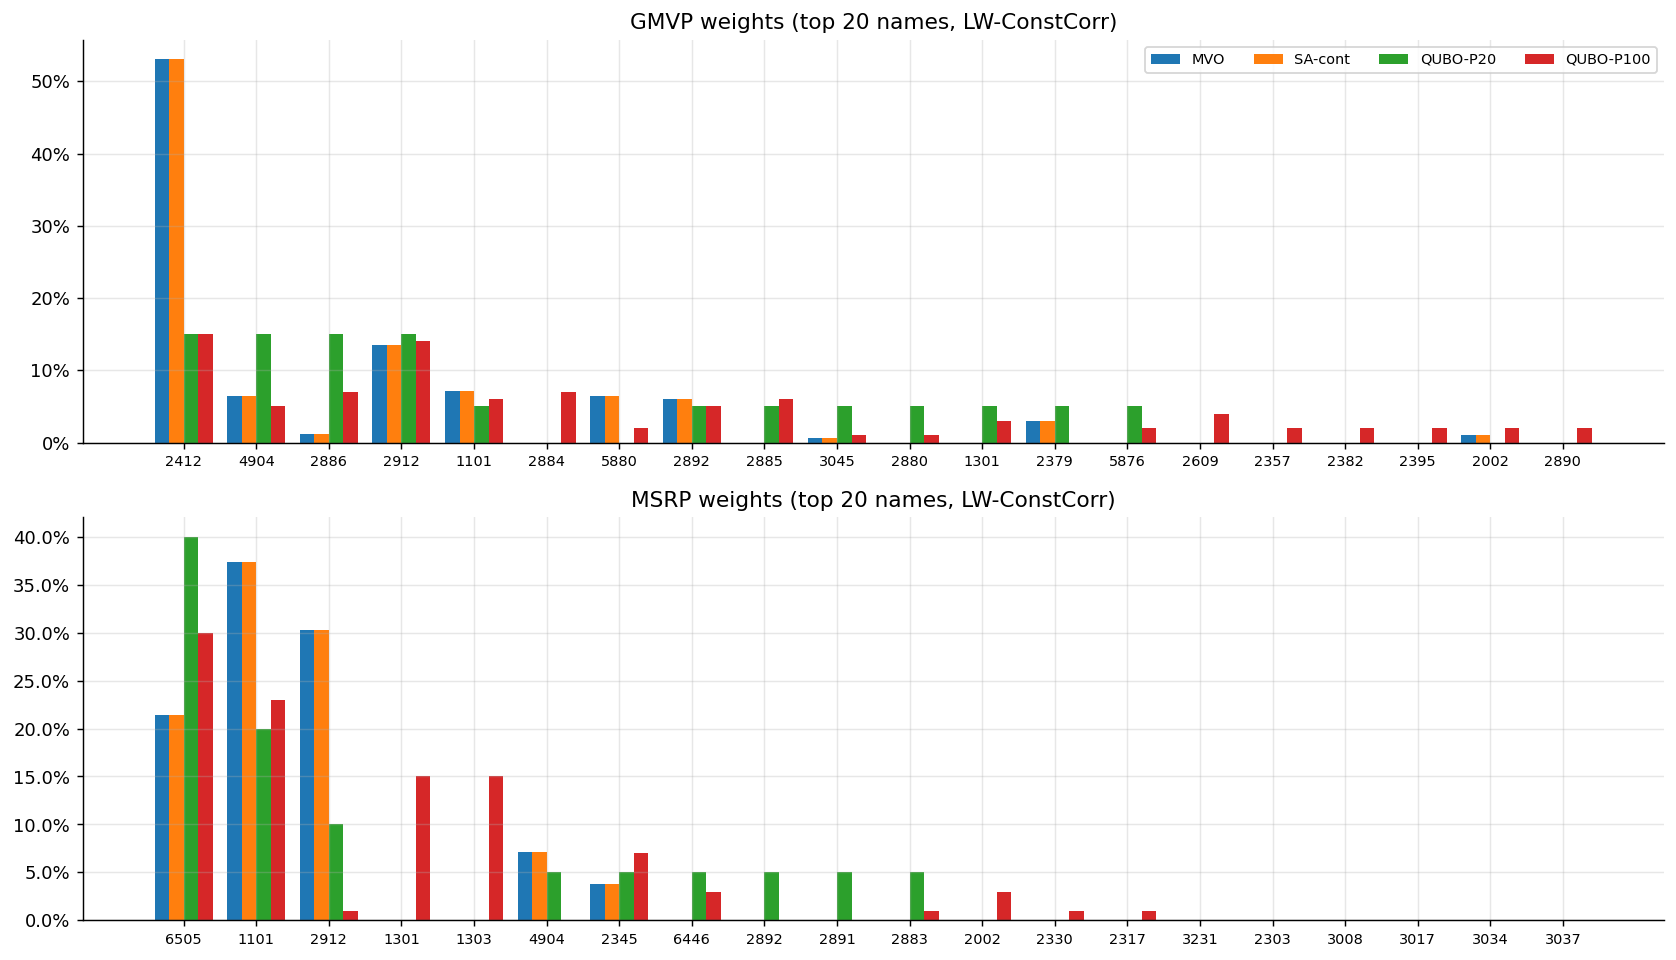

In [8]:
Image(filename=str(cfg["paths"]["results"] / "figures" / f"weights_{schedule[0].quarter}.png"))

In [9]:
pd.read_csv(SUMMARY / "concentration.csv", index_col=[0, 1])

eff_n  n_holdings  max_w
portfolio method                                   
NaN       EqualWeight    50.0000     50.0000 0.0200
GMVP      MVO             3.1710     12.7200 0.5258
          MVO-cap10      11.9023     19.0800 0.1000
          MVO-round-P100  3.1722     10.4400 0.5256
          MVO-round-P20   3.0130      5.5600 0.5340
          Oracle          5.5202     14.4000 0.3668
          QUBO-P100      13.5618     26.8800 0.1552
          QUBO-P20        6.9039     11.0000 0.2880
          SA-cont         3.1703     12.3600 0.5259
MSRP      MVO             4.6515      7.4400 0.3183
          MVO-cap10      11.3108     14.4400 0.1000
          MVO-round-P100  4.6450      7.0800 0.3184
          MVO-round-P20   4.6580      6.4800 0.3180
          Oracle          6.4445      9.4000 0.2565
          QUBO-P100       7.9693     17.1200 0.2612
          QUBO-P20        5.5277      8.0000 0.3200
          SA-cont         4.6516      7.4400 0.3183

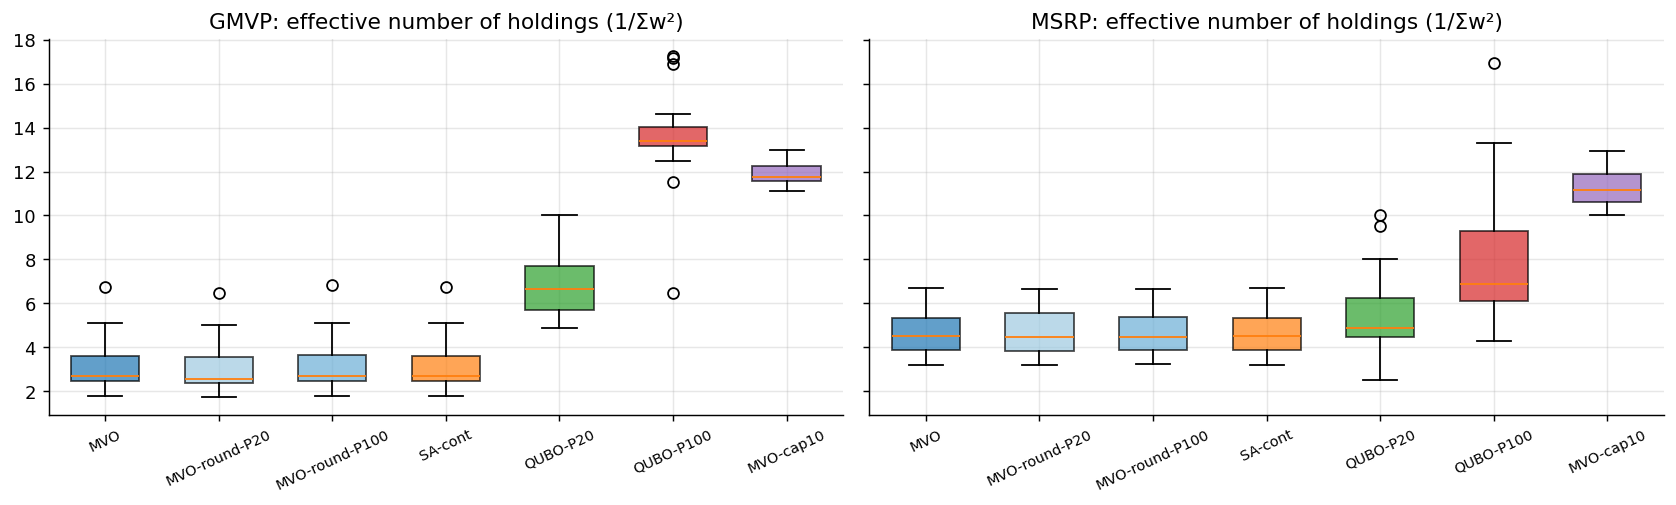

In [10]:
Image(filename=str(cfg["paths"]["results"] / "figures" / "concentration.png"))

**解讀**：QUBO 解明顯較分散（GMVP 有效持股數約 7～14 檔，MVO 約 3 檔），這並非刻意的正則化，而是退火沒有收斂到集中的最佳解的副產品。下一本 notebook 會檢驗這種分散在樣本外的影響，以及它能否被簡單的「10% 權重上限」複製。